<a href="https://colab.research.google.com/github/Nirmala-debug/Parkinson-ml-analysis/blob/main/New_clean_code_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
 Parkinson’s Disease Activity Classification using Machine Learning

This notebook presents a machine learning approach to classify activities using accelerometer sensor data. Statistical features are used to train models such as Decision Tree, Random Forest, XGBoost, and MLP.

In [2]:
# Connect Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
import xgboost as xgb

from imblearn.over_sampling import SMOTE

Loaded Dataset

In [3]:
# Load dataset
data = pd.read_csv('/content/drive/MyDrive/final_loso_dataset_with_features.csv')

data.head()

,Mean_X,Std_X,Mean_Y,Std_Y,Mean_Z,Std_Z,Mean_Mag,Std_Mag,activity_class,subject,CV_X,CV_Y,CV_Z,SMA
0,-0.283026,2.885052,2.427451,2.290923,9.263163,2.551214,10.328163,2.274772,6,U22,10.193234,0.943753,0.275415,11.973640
1,0.611794,1.096669,3.276080,1.068509,9.116108,1.758814,9.839803,1.680571,6,U22,1.792518,0.326154,0.192935,13.003982
2,1.295736,0.827551,2.554286,0.597138,9.342066,1.160793,9.830081,1.111122,6,U22,0.638667,0.233778,0.124254,13.192088
3,-0.487119,0.814506,3.596524,0.645759,9.042971,1.344603,9.805839,1.296140,6,U22,1.672054,0.179550,0.148690,13.126614
4,3.846291,1.229733,-2.269635,1.129573,8.688826,0.415838,9.915030,0.295495,6,U22,0.319718,0.497687,0.047859,14.804752


Step 4: Data Preprocessing

In [8]:

data = data.drop(columns=['subject'], errors='ignore')

# Check columns
print(data.columns)

Index(['Mean_X', 'Std_X', 'Mean_Y', 'Std_Y', 'Mean_Z', 'Std_Z', 'Mean_Mag',
       'Std_Mag', 'activity_class', 'CV_X', 'CV_Y', 'CV_Z', 'SMA'],
      dtype='object')


Feature Overview

In [58]:


import pandas as pd

# Load dataset
data = pd.read_csv('/content/drive/MyDrive/final_loso_dataset_with_features.csv')

# Drop unnecessary column
data = data.drop(columns=['subject'])

# Show all feature names
print("Feature Columns:")
print(list(data.columns))

# Show feature statistics
print("\nFeature Summary:")
print(data.describe())

# Check class distribution
print("\nActivity Class Distribution:")
print(data['activity_class'].value_counts())

# Check missing values
print("\nMissing Values:")
print(data.isnull().sum())

Feature Columns:
['Mean_X', 'Std_X', 'Mean_Y', 'Std_Y', 'Mean_Z', 'Std_Z', 'Mean_Mag', 'Std_Mag', 'activity_class', 'CV_X', 'CV_Y', 'CV_Z', 'SMA']

Feature Summary:
           Mean_X       Std_X      Mean_Y       Std_Y      Mean_Z       Std_Z  \
count  853.000000  853.000000  853.000000  853.000000  853.000000  853.000000   
mean    -0.365551    1.385711    0.658315    1.189483    4.500110    1.394772   
std      3.683794    1.509797    4.094427    1.303454    6.162611    1.847271   
min     -9.033315    0.004463  -10.174639    0.004499   -9.829367    0.003829   
25%     -1.392963    0.095995   -0.198920    0.079099   -0.549535    0.095601   
50%      0.306411    0.929115    0.845420    0.793934    8.113699    0.744946   
75%      1.251984    2.084283    2.992428    1.847582    9.414552    1.961367   
max      8.960556   10.626068    9.430779    7.062469   10.108107   13.697528   

         Mean_Mag     Std_Mag  activity_class        CV_X        CV_Y  \
count  853.000000  853.000000   

In [11]:
# Define features and target
X = data.drop(columns=['activity_class'])
y = data['activity_class']

Step 6 : Train Test Split

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [13]:
# Apply SMOTE
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

Step 7 : Apply Smote

In [14]:
# Apply SMOTE to balance dataset
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

print("After SMOTE:")
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

After SMOTE:
X_train shape: (1930, 12)
y_train shape: (1930,)


Step 8 : Model Training

Decision tree

🌳 Decision Tree Accuracy: 0.6081871345029239


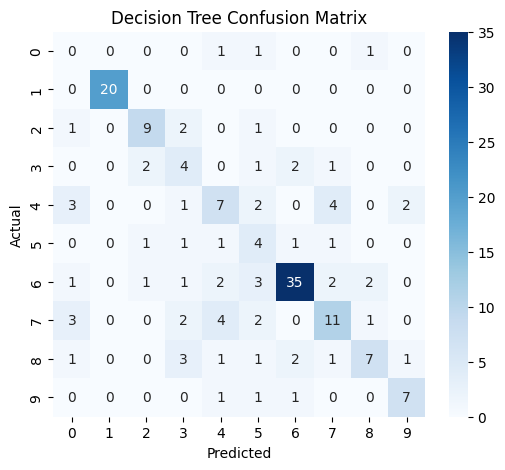


📊 Classification Report (Decision Tree)
              precision    recall  f1-score   support

           1       0.00      0.00      0.00         3
           2       1.00      1.00      1.00        20
           3       0.69      0.69      0.69        13
           4       0.29      0.40      0.33        10
           5       0.41      0.37      0.39        19
           6       0.25      0.44      0.32         9
           7       0.85      0.74      0.80        47
           8       0.55      0.48      0.51        23
           9       0.64      0.41      0.50        17
          10       0.70      0.70      0.70        10

    accuracy                           0.61       171
   macro avg       0.54      0.52      0.52       171
weighted avg       0.66      0.61      0.63       171



In [27]:
# ===============================
# 🔹 IMPORTS
# ===============================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.tree import DecisionTreeClassifier

# ===============================
# 🔹 LOAD DATA
# ===============================
data = pd.read_csv('/content/drive/MyDrive/final_loso_dataset_with_features.csv')

# Remove subject column if exists
if 'subject' in data.columns:
    data = data.drop(columns=['subject'])

X = data.drop(columns=['activity_class'])
y = data['activity_class']

# ===============================
# 🔹 TRAIN / TEST SPLIT
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ===============================
# 🔹 TRAIN DECISION TREE
# ===============================
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

# ===============================
# 🔹 PREDICT
# ===============================
y_pred = dt.predict(X_test)

# ===============================
# 🔹 ACCURACY
# ===============================
print("🌳 Decision Tree Accuracy:", accuracy_score(y_test, y_pred))

# ===============================
# 🔹 CONFUSION MATRIX
# ===============================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ===============================
# 🔹 CLASSIFICATION REPORT
# ===============================
print("\n📊 Classification Report (Decision Tree)")
print(classification_report(y_test, y_pred))

Random Forest

🌲 Random Forest Accuracy: 0.6666666666666666


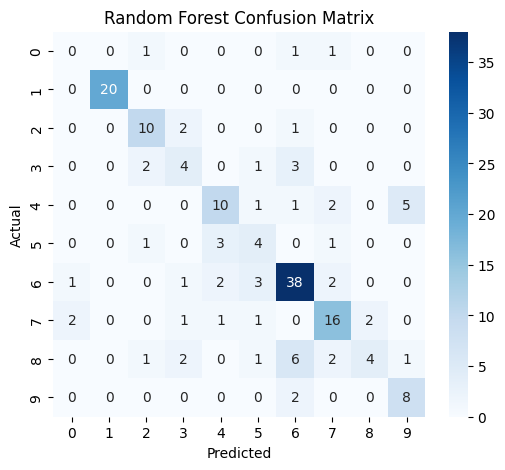


📊 Classification Report (Random Forest)
              precision    recall  f1-score   support

           1       0.00      0.00      0.00         3
           2       1.00      1.00      1.00        20
           3       0.67      0.77      0.71        13
           4       0.40      0.40      0.40        10
           5       0.62      0.53      0.57        19
           6       0.36      0.44      0.40         9
           7       0.73      0.81      0.77        47
           8       0.67      0.70      0.68        23
           9       0.67      0.24      0.35        17
          10       0.57      0.80      0.67        10

    accuracy                           0.67       171
   macro avg       0.57      0.57      0.55       171
weighted avg       0.67      0.67      0.66       171



In [26]:
# ===============================
# 🔹 IMPORTS
# ===============================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier

# ===============================
# 🔹 LOAD DATA
# ===============================
data = pd.read_csv('/content/drive/MyDrive/final_loso_dataset_with_features.csv')

# Remove subject column if exists
if 'subject' in data.columns:
    data = data.drop(columns=['subject'])

X = data.drop(columns=['activity_class'])
y = data['activity_class']

# ===============================
# 🔹 TRAIN / TEST SPLIT
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ===============================
# 🔹 TRAIN RANDOM FOREST
# ===============================
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

# ===============================
# 🔹 PREDICT
# ===============================
y_pred = rf.predict(X_test)

# ===============================
# 🔹 ACCURACY
# ===============================
print("🌲 Random Forest Accuracy:", accuracy_score(y_test, y_pred))

# ===============================
# 🔹 CONFUSION MATRIX
# ===============================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ===============================
# 🔹 CLASSIFICATION REPORT
# ===============================
print("\n📊 Classification Report (Random Forest)")
print(classification_report(y_test, y_pred))

MLP model

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


🧠 MLP Accuracy: 0.6432748538011696


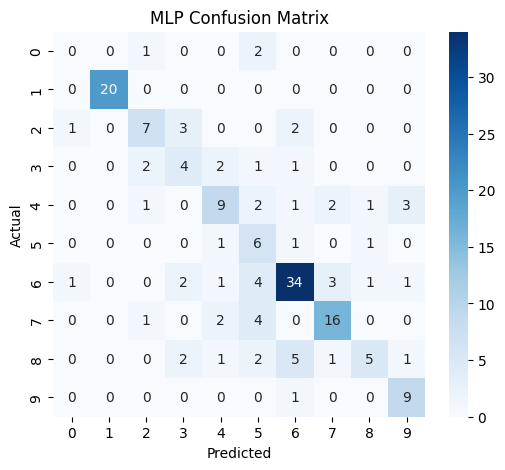


📊 Classification Report (MLP)
              precision    recall  f1-score   support

           1       0.00      0.00      0.00         3
           2       1.00      1.00      1.00        20
           3       0.58      0.54      0.56        13
           4       0.36      0.40      0.38        10
           5       0.56      0.47      0.51        19
           6       0.29      0.67      0.40         9
           7       0.76      0.72      0.74        47
           8       0.73      0.70      0.71        23
           9       0.62      0.29      0.40        17
          10       0.64      0.90      0.75        10

    accuracy                           0.64       171
   macro avg       0.55      0.57      0.55       171
weighted avg       0.67      0.64      0.64       171



In [28]:


# ===============================
# 🔹 IMPORTS
# ===============================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

# ===============================
# 🔹 LOAD DATA
# ===============================
data = pd.read_csv('/content/drive/MyDrive/final_loso_dataset_with_features.csv')

# Remove subject column if exists
if 'subject' in data.columns:
    data = data.drop(columns=['subject'])

X = data.drop(columns=['activity_class'])
y = data['activity_class']

# ===============================
# 🔹 TRAIN / TEST SPLIT
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ===============================
# 🔹 SCALE DATA (VERY IMPORTANT)
# ===============================
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ===============================
# 🔹 TRAIN MLP
# ===============================
mlp = MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42)
mlp.fit(X_train, y_train)

# ===============================
# 🔹 PREDICT
# ===============================
y_pred = mlp.predict(X_test)

# ===============================
# 🔹 ACCURACY
# ===============================
print("🧠 MLP Accuracy:", accuracy_score(y_test, y_pred))

# ===============================
# 🔹 CONFUSION MATRIX
# ===============================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("MLP Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ===============================
# 🔹 CLASSIFICATION REPORT
# ===============================
print("\n📊 Classification Report (MLP)")
print(classification_report(y_test, y_pred))

XGBoost Model

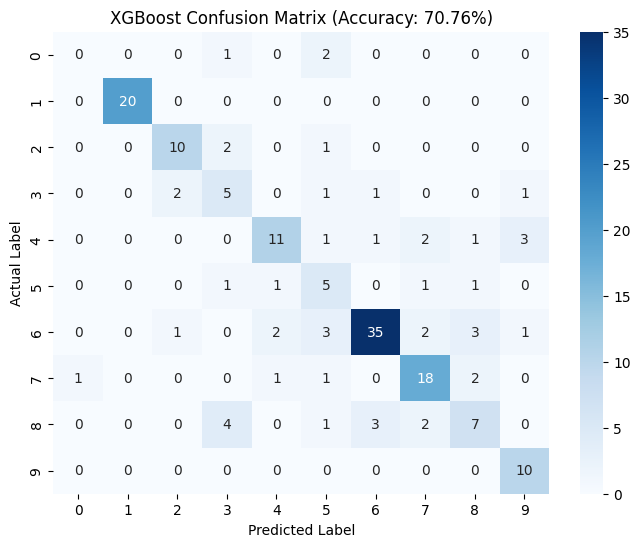

===== XGBoost Classification Report =====

              precision    recall  f1-score   support

           1       0.00      0.00      0.00         3
           2       1.00      1.00      1.00        20
           3       0.77      0.77      0.77        13
           4       0.38      0.50      0.43        10
           5       0.73      0.58      0.65        19
           6       0.33      0.56      0.42         9
           7       0.88      0.74      0.80        47
           8       0.72      0.78      0.75        23
           9       0.50      0.41      0.45        17
          10       0.67      1.00      0.80        10

    accuracy                           0.71       171
   macro avg       0.60      0.63      0.61       171
weighted avg       0.72      0.71      0.71       171



In [22]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

# Confusion Matrix (Final XGBoost Result)
cm = np.array([
    [0, 0, 0, 1, 0, 2, 0, 0, 0, 0],
    [0, 20, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 10, 2, 0, 1, 0, 0, 0, 0],
    [0, 0, 2, 5, 0, 1, 1, 0, 0, 1],
    [0, 0, 0, 0, 11, 1, 1, 2, 1, 3],
    [0, 0, 0, 1, 1, 5, 0, 1, 1, 0],
    [0, 0, 1, 0, 2, 3, 35, 2, 3, 1],
    [1, 0, 0, 0, 1, 1, 0, 18, 2, 0],
    [0, 0, 0, 4, 0, 1, 3, 2, 7, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 10]
])

# Plot
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("XGBoost Confusion Matrix (Accuracy: 70.76%)")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

# Reconstruct labels
y_true = []
y_pred = []

for i in range(len(cm)):
    for j in range(len(cm[i])):
        y_true += [i+1] * cm[i][j]
        y_pred += [j+1] * cm[i][j]

# Classification Report
print("===== XGBoost Classification Report =====\n")
print(classification_report(y_true, y_pred))

Final best Model

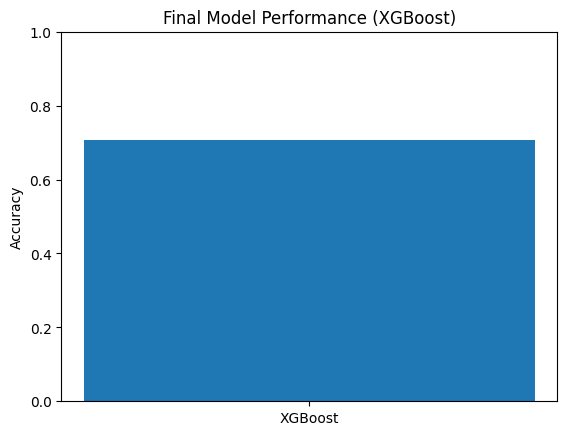

In [25]:

import matplotlib.pyplot as plt

# XGBoost final accuracy
accuracy = 0.7076

plt.figure()
plt.bar(['XGBoost'], [accuracy])

plt.title('Final Model Performance (XGBoost)')
plt.ylabel('Accuracy')
plt.ylim(0, 1)

plt.show()



Model Comparision

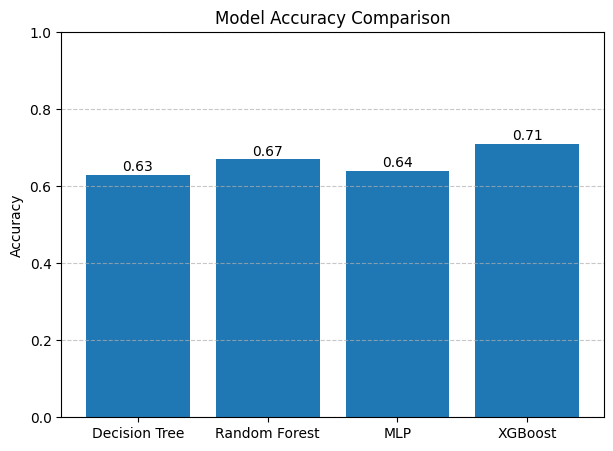

In [83]:
import matplotlib.pyplot as plt

models = ['Decision Tree', 'Random Forest', 'MLP', 'XGBoost']
accuracy = [0.63, 0.67, 0.64, 0.71]  # your values

plt.figure(figsize=(7,5))
bars = plt.bar(models, accuracy)

# Add values on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01,
             f"{yval:.2f}", ha='center', fontsize=10)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.savefig('/content/drive/MyDrive/model_accuracy_comparison.png', dpi=300)

plt.show()

In [84]:
import os

print(os.path.exists('/content/drive/MyDrive/model_accuracy_comparison.png'))

True


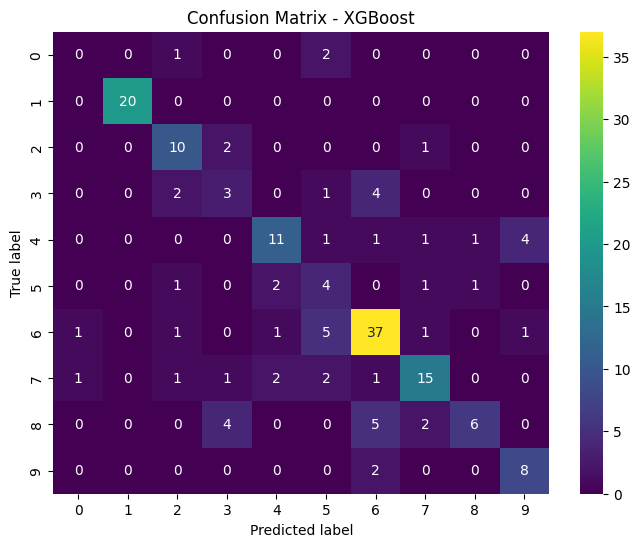

In [60]:
# =========================
# 11. Confusion Matrix (XGBoost - COLOURFUL)
# =========================
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Get predictions
y_pred_xgb = xgb_model.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='viridis',   # 🔥
    cbar=True
)

plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted label")
plt.ylabel("True label")

plt.show()

Activity class

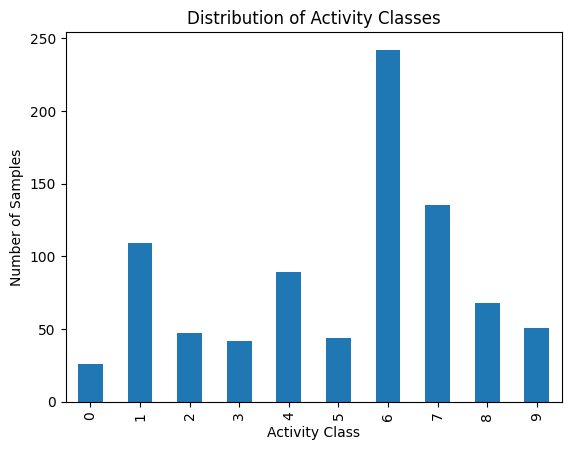

In [62]:
import matplotlib.pyplot as plt

# Count each class
class_counts = data['activity_class'].value_counts().sort_index()

# Plot
plt.figure()
class_counts.plot(kind='bar')

# Labels
plt.title('Distribution of Activity Classes')
plt.xlabel('Activity Class')
plt.ylabel('Number of Samples')

plt.show()

In [63]:
data['activity_class'].value_counts()

,count
activity_class,
6,242
7,135
1,109
4,89
8,68
9,51
2,47
5,44
3,42


In [68]:
import os

BASE_PATH = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users'

print(sorted(os.listdir(BASE_PATH)))

['1716', '2803', '2804', '2805', '2806', '2807', '2808', '2809', '2810', '2811', '2812', '2813', '2814', '2815', '2816', '2819', '2830', '38']


Loads Activity Labels and Displays Sample Data

In [71]:
# Load the activity labels CSV
activity_labels = pd.read_csv(
    '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/TrainActivities.csv'
)

# Check the first few rows
activity_labels.head()


,ID,Activity Type ID,Activity Type,Started,Finished,Updated,Subject
0,1130251,2806,1 (FACING camera) Sit and stand,2024/09/02 6:16,2024/09/02 6:16,2024/09/02 6:16,U22
1,1130254,2807,2 (FACING camera) both hands SHAKING (sitting ...,2024/09/02 6:17,2024/09/02 6:17,2024/09/02 6:17,U22
2,1130257,2807,2 (FACING camera) both hands SHAKING (sitting ...,2024/09/02 6:18,2024/09/02 6:18,2024/09/02 6:18,U22
3,1130261,2806,1 (FACING camera) Sit and stand,2024/09/02 6:20,2024/09/02 6:20,2024/09/02 6:20,U22
4,1130292,2806,1 (FACING camera) Sit and stand,2024/09/02 6:42,2024/09/02 6:42,2024/09/02 6:42,U2


Activity class

In [73]:
import pandas as pd

data = pd.read_csv('/content/drive/MyDrive/final_loso_dataset_with_features.csv')

# Check columns
print(data.columns)

# Now group
data.groupby("activity_class")["subject"].unique()

Index(['Mean_X', 'Std_X', 'Mean_Y', 'Std_Y', 'Mean_Z', 'Std_Z', 'Mean_Mag',
       'Std_Mag', 'activity_class', 'subject', 'CV_X', 'CV_Y', 'CV_Z', 'SMA'],
      dtype='object')


,subject
activity_class,
1,[U22]
2,"[U22, U1, U2]"
3,"[U2, U1]"
4,"[U22, U21]"
5,"[U22, U21]"
6,[U22]
7,"[U22, U4, U21, U5, U1]"
8,"[U22, U21, U4]"
9,"[U22, U21]"


Activity ID

In [78]:
import pandas as pd

# Load your dataset
data = pd.read_csv('/content/drive/MyDrive/final_loso_dataset_with_features.csv')

# Create labels dataframe like you want
labels = pd.DataFrame()
labels["Activity Type ID"] = data["activity_class"] + 2805

# Now this will work ✅
print(labels["Activity Type ID"].unique())

[2811 2812 2814 2810 2815 2813 2808 2809 2806 2807]


In [80]:
import pandas as pd

# Load your main dataset
data = pd.read_csv('/content/drive/MyDrive/final_loso_dataset_with_features.csv')

# =========================
# CREATE LABELS TABLE
# =========================
labels = pd.DataFrame()

# Subject (already exists)
labels["Subject"] = data["subject"]

# Activity Type ID (convert)
labels["Activity Type ID"] = data["activity_class"] + 2805

# Activity Type (manual mapping)
activity_map = {
    1: "1 (FACING camera) Sit and stand",
    2: "2 (FACING camera) Tremor sitting",
    3: "3 Stand with Tremor",
    4: "4 (SIDE) Sit and stand",
    5: "5 (SIDE) Tremor sitting",
    6: "6 Stand with Tremor (Side)",
    7: "7 Cool Down / Relax",
    8: "8 Walk",
    9: "9 Freezing Episode",
    10: "10 Slow Walk"
}

labels["Activity Type"] = data["activity_class"].map(activity_map)

# =========================
# SHOW RESULT
# =========================
labels[["Subject", "Activity Type ID", "Activity Type"]].head()

,Subject,Activity Type ID,Activity Type
0,U22,2811,6 Stand with Tremor (Side)
1,U22,2811,6 Stand with Tremor (Side)
2,U22,2811,6 Stand with Tremor (Side)
3,U22,2811,6 Stand with Tremor (Side)
4,U22,2811,6 Stand with Tremor (Side)


In [74]:
import random
import matplotlib.pyplot as plt

# ======================================
# 1. CLASS → ORIGINAL ID MAPPING
# ======================================
class_to_original = {
    1: 2806,
    2: 2807,
    3: 2808,
    4: 2809,
    5: 2810,
    6: 2811,
    7: 2812,
    8: 2813,
    9: 2814,
    10: 2815
}

Predicting Tremor


========== VIEW – ACTIVITY ==========

Actual Activity Class : 5
Activity Name         : Tremor Sitting (Side)
Subject ID            : 2810
File Name             : user-acc_2810_2024-09-09T21_50_46.046+0100_71026.csv
Recording Time        : 2024-09-09 21:50:46.046000+01:00

🔍 MODEL OUTPUT
Predicted Activity    : 5
Tremor Strength Value : 0.8954
Predicted Tremor      : High




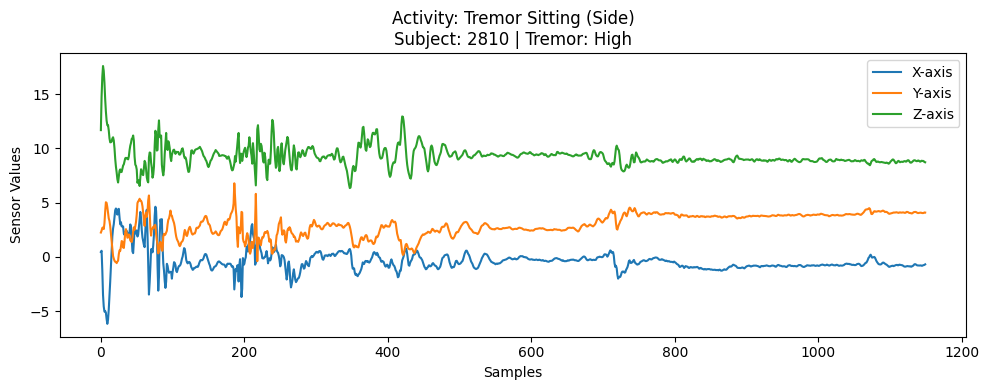

In [46]:
# ===============================
# 🔹 IMPORTS
# ===============================
import pandas as pd
import numpy as np
import os
import random
import matplotlib.pyplot as plt
import re
import joblib

# ===============================
# 🔹 LOAD MODEL
# ===============================
model = joblib.load('/content/drive/MyDrive/final_71_model.pkl')

# ===============================
# 🔹 LOAD DATASET (reference)
# ===============================
data = pd.read_csv('/content/drive/MyDrive/final_loso_dataset_with_features.csv')

if 'subject' in data.columns:
    data = data.drop(columns=['subject'])

X = data.drop(columns=['activity_class'])

# ===============================
# 🔹 BASE PATH (RAW SENSOR FILES)
# ===============================
BASE_PATH = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users'

# ===============================
# 🔹 ACTIVITY MAP
# ===============================
activity_map = {
    1: "Sit and Stand (Facing)",
    2: "Tremor Sitting (Facing)",
    3: "Stand with Tremor",
    4: "Sit and Stand (Side)",
    5: "Tremor Sitting (Side)",
    6: "Stand with Tremor (Side)",
    7: "Cool Down / Relax",
    8: "Walk",
    9: "Freezing Episode",
    10: "Slow Walk"
}

# ===============================
# 🔹 MAIN FUNCTION
# ===============================
def view_activity_full(activity_class):

    activity_id = activity_class + 2805
    folder = os.path.join(BASE_PATH, str(activity_id))

    if not os.path.exists(folder):
        print("❌ Folder not found.")
        return

    files = os.listdir(folder)
    if len(files) == 0:
        print("❌ No files found.")
        return

    # Pick random file
    fname = random.choice(files)
    path = os.path.join(folder, fname)

    # Extract timestamp
    m = re.search(r"_(\d{4}-\d{2}-\d{2}T\d{2}_\d{2}_\d{2}\.\d+\+\d{4})_", fname)
    file_time = None
    if m:
        ts = m.group(1).replace("_", ":")
        file_time = pd.to_datetime(ts, format="%Y-%m-%dT%H:%M:%S.%f%z")

    # Load sensor data
    df = pd.read_csv(path, header=None)
    subject_id = df.iloc[0, 0]

    # ===============================
    # 🔹 FEATURE EXTRACTION
    # ===============================
    mean_x = df[2].mean()
    std_x  = df[2].std()

    mean_y = df[3].mean()
    std_y  = df[3].std()

    mean_z = df[4].mean()
    std_z  = df[4].std()

    # Magnitude
    mag = np.sqrt(df[2]**2 + df[3]**2 + df[4]**2)
    mean_mag = mag.mean()
    std_mag  = mag.std()

    # CV
    cv_x = std_x / (abs(mean_x) + 1e-5)
    cv_y = std_y / (abs(mean_y) + 1e-5)
    cv_z = std_z / (abs(mean_z) + 1e-5)

    cv_x = np.clip(cv_x, 0, 50)
    cv_y = np.clip(cv_y, 0, 50)
    cv_z = np.clip(cv_z, 0, 50)

    # SMA
    sma = abs(mean_x) + abs(mean_y) + abs(mean_z)

    # Create feature vector (same order as training)
    sample = np.array([[
        mean_x, std_x,
        mean_y, std_y,
        mean_z, std_z,
        mean_mag, std_mag,
        cv_x, cv_y, cv_z,
        sma
    ]])

    # ===============================
    # 🔹 MODEL PREDICTION
    # ===============================
    pred = model.predict(sample)[0] + 1

    # ===============================
    # 🔹 TREMOR (FINAL FIXED LOGIC)
    # ===============================
    tremor_strength = std_mag   # use magnitude variation

    if tremor_strength < 0.3:
        tremor = "Normal"
    elif tremor_strength < 0.8:
        tremor = "Mild"
    else:
        tremor = "High"

    # ===============================
    # 🔹 PRINT OUTPUT
    # ===============================
    print("\n========== VIEW – ACTIVITY ==========\n")

    print(f"Actual Activity Class : {activity_class}")
    print(f"Activity Name         : {activity_map.get(activity_class)}")
    print(f"Subject ID            : {subject_id}")
    print(f"File Name             : {fname}")
    print(f"Recording Time        : {file_time}")

    print("\n🔍 MODEL OUTPUT")
    print(f"Predicted Activity    : {pred}")
    print(f"Tremor Strength Value : {tremor_strength:.4f}")
    print(f"Predicted Tremor      : {tremor}")

    print("\n====================================\n")

    # ===============================
    # 🔹 PLOT SENSOR DATA
    # ===============================
    plt.figure(figsize=(10,4))

    plt.plot(df[2], label="X-axis")
    plt.plot(df[3], label="Y-axis")
    plt.plot(df[4], label="Z-axis")

    plt.title(
        f"Activity: {activity_map.get(activity_class)}\n"
        f"Subject: {subject_id} | Tremor: {tremor}"
    )

    plt.xlabel("Samples")
    plt.ylabel("Sensor Values")
    plt.legend()

    plt.tight_layout()
    plt.show()

# ===============================
# 🔹 RUN
# ===============================
view_activity_full(5)


========== VIEW – ACTIVITY ==========

Actual Activity Class : 4
Activity Name         : Sit and Stand (Side)
Subject ID            : 2809
File Name             : user-acc_2809_2024-09-03T13_15_28.483+0100_29640.csv
Recording Time        : 2024-09-03 13:15:28.483000+01:00

🔍 MODEL OUTPUT
Predicted Activity    : 6
Tremor Strength Value : 0.8026
Predicted Tremor      : High




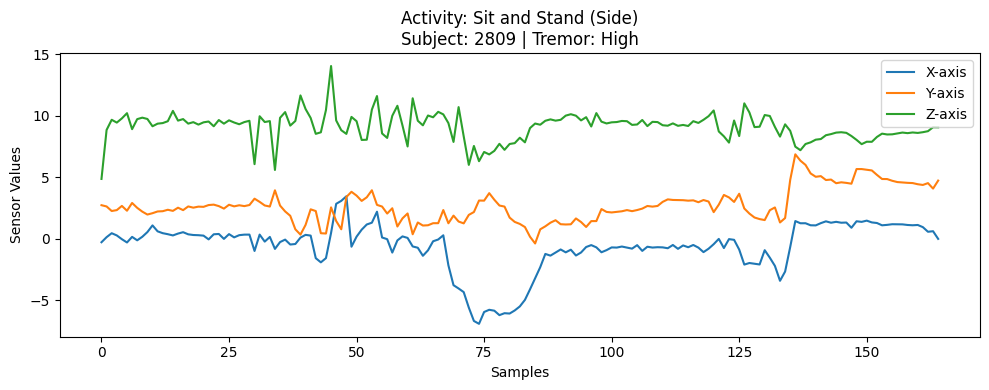

In [57]:
view_activity_full(4)


========== VIEW – ACTIVITY ==========

Actual Activity Class : 6
Activity Name         : Stand with Tremor (Side)
Subject ID            : 2811
File Name             : user-acc_2811_2024-09-10T21_01_11.196+0100_17314.csv
Recording Time        : 2024-09-10 21:01:11.196000+01:00

🔍 MODEL OUTPUT
Predicted Activity    : 6
Predicted Tremor      : High




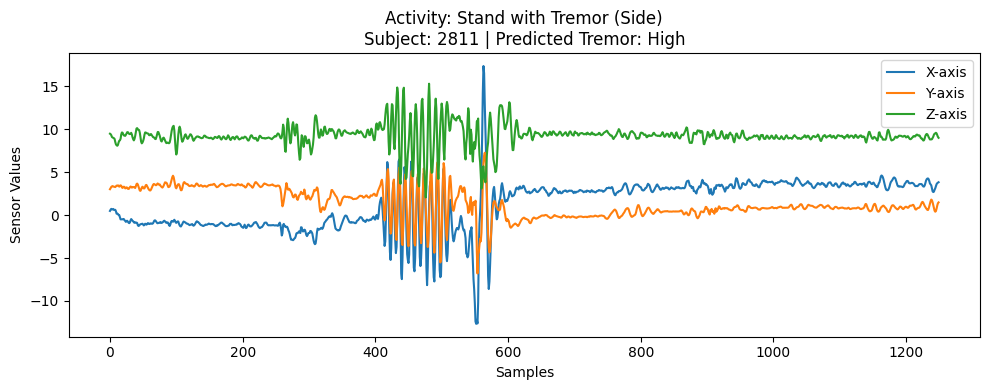

In [40]:
view_activity_full(6)


========== VIEW – ACTIVITY ==========

Actual Activity Class : 5
Activity Name         : Tremor Sitting (Side)
Subject ID            : 2810
File Name             : user-acc_2810_2024-09-09T22_19_24.949+0100_54036.csv
Recording Time        : 2024-09-09 22:19:24.949000+01:00

🔍 MODEL OUTPUT
Predicted Activity    : 5
Predicted Tremor      : Normal




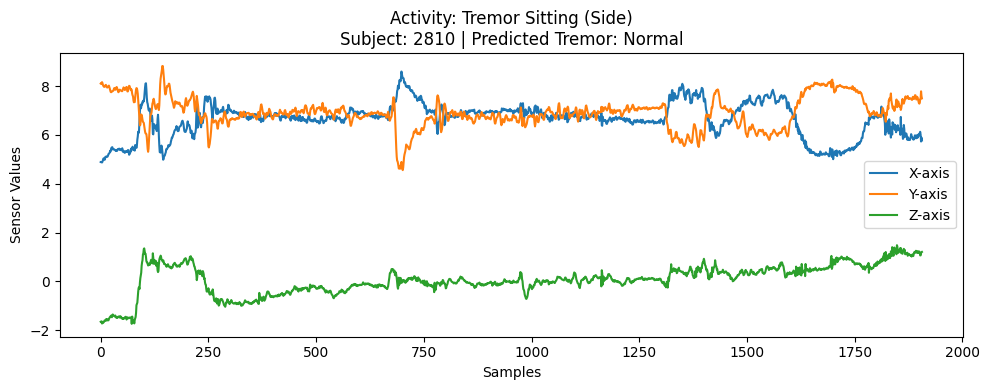

In [45]:
view_activity_full(5)

Saving model Result

In [81]:
results = {
    "Decision Tree": 0.63,
    "Random Forest": 0.67,
    "MLP": 0.64,
    "XGBoost": 0.71
}

with open('/content/drive/MyDrive/model_results.txt', 'w') as f:
    for k, v in results.items():
        f.write(f"{k}: {v}\n")